In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

In [2]:
df = pd.read_csv("/content/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

In [3]:
print("Shape:", df.shape)
print("Columns:", df.columns)

Shape: (225745, 79)
Columns: Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std',

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             225745 non-null  int64  
 1    Flow Duration                225745 non-null  int64  
 2    Total Fwd Packets            225745 non-null  int64  
 3    Total Backward Packets       225745 non-null  int64  
 4   Total Length of Fwd Packets   225745 non-null  int64  
 5    Total Length of Bwd Packets  225745 non-null  int64  
 6    Fwd Packet Length Max        225745 non-null  int64  
 7    Fwd Packet Length Min        225745 non-null  int64  
 8    Fwd Packet Length Mean       225745 non-null  float64
 9    Fwd Packet Length Std        225745 non-null  float64
 10  Bwd Packet Length Max         225745 non-null  int64  
 11   Bwd Packet Length Min        225745 non-null  int64  
 12   Bwd Packet Length Mean       225745 non-nul

In [6]:
print(df.head(10))

    Destination Port   Flow Duration   Total Fwd Packets  \
0              54865               3                   2   
1              55054             109                   1   
2              55055              52                   1   
3              46236              34                   1   
4              54863               3                   2   
5              54871            1022                   2   
6              54925               4                   2   
7              54925              42                   1   
8               9282               4                   2   
9              55153               4                   2   

    Total Backward Packets  Total Length of Fwd Packets  \
0                        0                           12   
1                        1                            6   
2                        1                            6   
3                        1                            6   
4                        0                  

In [7]:
for col in df.columns:
    print(col)

 Destination Port
 Flow Duration
 Total Fwd Packets
 Total Backward Packets
Total Length of Fwd Packets
 Total Length of Bwd Packets
 Fwd Packet Length Max
 Fwd Packet Length Min
 Fwd Packet Length Mean
 Fwd Packet Length Std
Bwd Packet Length Max
 Bwd Packet Length Min
 Bwd Packet Length Mean
 Bwd Packet Length Std
Flow Bytes/s
 Flow Packets/s
 Flow IAT Mean
 Flow IAT Std
 Flow IAT Max
 Flow IAT Min
Fwd IAT Total
 Fwd IAT Mean
 Fwd IAT Std
 Fwd IAT Max
 Fwd IAT Min
Bwd IAT Total
 Bwd IAT Mean
 Bwd IAT Std
 Bwd IAT Max
 Bwd IAT Min
Fwd PSH Flags
 Bwd PSH Flags
 Fwd URG Flags
 Bwd URG Flags
 Fwd Header Length
 Bwd Header Length
Fwd Packets/s
 Bwd Packets/s
 Min Packet Length
 Max Packet Length
 Packet Length Mean
 Packet Length Std
 Packet Length Variance
FIN Flag Count
 SYN Flag Count
 RST Flag Count
 PSH Flag Count
 ACK Flag Count
 URG Flag Count
 CWE Flag Count
 ECE Flag Count
 Down/Up Ratio
 Average Packet Size
 Avg Fwd Segment Size
 Avg Bwd Segment Size
 Fwd Header Length.1
Fwd Avg

Before Encoding:
 Label
1    225745
Name: count, dtype: int64
After Encoding:
 Label
1    225745
Name: count, dtype: int64


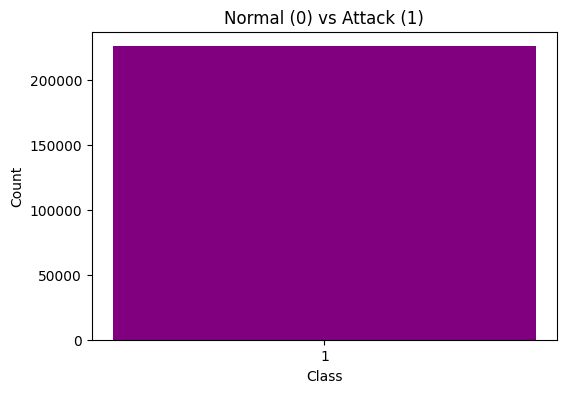

In [12]:
df.columns = df.columns.str.strip()

print("Before Encoding:\n", df['Label'].value_counts())

# Encode Labels using map instead of lambda
df['Label'] = df['Label'].map({'BENIGN': 0}).fillna(1).astype(int)

print("After Encoding:\n", df['Label'].value_counts())

plt.figure(figsize=(6,4))
plt.bar(df['Label'].value_counts().index.astype(str),
        df['Label'].value_counts().values,
        color=['purple','red'])
plt.title('Normal (0) vs Attack (1)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [13]:
#drop duplicates
df.drop_duplicates(inplace=True)

In [15]:
df = df.drop_duplicates()
df=df.replace([np.inf, -np.inf], np.nan)
df=df.dropna()
print("Duplicates rows", df.duplicated().sum())

Duplicates rows 0


In [17]:
X = pd.get_dummies(X, drop_first=True)

NameError: name 'X' is not defined

In [18]:
# Separate features (X) and target (y)
X = df.drop('Label', axis=1)
y = df['Label']

In [19]:
X = pd.get_dummies(X, drop_first=True)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [21]:
print("Class distribution in dataset:")
print(df['Label'].value_counts())

print("\ny_train distribution:")
print(pd.value_counts(y_train))

print("\ny_test distribution:")
print(pd.value_counts(y_test))

Class distribution in dataset:
Label
1    223082
Name: count, dtype: int64

y_train distribution:
Label
1    156157
Name: count, dtype: int64

y_test distribution:
Label
1    66925
Name: count, dtype: int64


/tmp/ipython-input-1106627563.py:5: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  print(pd.value_counts(y_train))
/tmp/ipython-input-1106627563.py:8: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  print(pd.value_counts(y_test))


In [22]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test_power = scaler.transform(X_test)

In [23]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100),
}

plt.figure(figsize=(8,6))

for model_name, clf in models.items():
    print(f"\n>>> Training & Evaluating: {model_name}")

    clf.fit(X_train, y_train)
    predictions = clf.predict(X_test_power)

    # Metrics
    accuracy = accuracy_score(y_test, predictions)
    matrix = confusion_matrix(y_test, predictions)
    report = classification_report(y_test, predictions, digits=4)

    print(f"Accuracy: {accuracy:.4f}")
    print("Confusion Matrix:\n", matrix)
    print("Classification Report:\n", report)


>>> Training & Evaluating: Logistic Regression


ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: np.int64(1)

<Figure size 800x600 with 0 Axes>